Feature scaling is a data preprocessing technique in machine learning used to
standardize the range of independent features in a dataset. This process transforms the values of different features to a common scale, ensuring that no single feature, due to its naturally larger magnitude or range, disproportionately influences the model's learning process

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from io import StringIO

from seaborn import load_dataset
from sklearn.preprocessing import StandardScaler #mean centering
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [100]:
url="https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day20-univariate-analysis/train.csv"
req=requests.get(url).text
data=StringIO(req)
df=pd.read_csv(data)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [101]:
df.drop(columns=['PassengerId','Name',"Cabin",'Ticket',"Embarked","Sex"],axis=1,inplace=True)

In [102]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [103]:
x

,Pclass,Age,SibSp,Parch,Fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,3,35.0,0,0,8.0500
...,...,...,...,...,...
886,2,27.0,0,0,13.0000
887,1,19.0,0,0,30.0000
888,3,NaN,1,2,23.4500
889,1,26.0,0,0,30.0000


In [104]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [105]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.23,random_state=0)
cols=x_train.columns

In [106]:
ss=StandardScaler()
x_trained_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [107]:
cols

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [108]:
x_trained_scaled

array([[-0.37163042,  0.01671531,  0.39810741, -0.47958473, -0.16687917],
       [ 0.8252638 ,  0.08557243,  0.39810741, -0.47958473, -0.28486527],
       [ 0.8252638 ,  0.15442955, -0.46613843, -0.47958473, -0.47438044],
       ...,
       [ 0.8252638 ,         nan, -0.46613843, -0.47958473, -0.48675325],
       [ 0.8252638 ,  0.42985801,  0.39810741, -0.47958473, -0.29666388],
       [-0.37163042,  2.08242879,  0.39810741,  0.72552562,  0.12808607]])

In [109]:
x_trained=pd.DataFrame(x_trained_scaled,columns=cols)
x_tested=pd.DataFrame(x_test_scaled,columns=cols)

In [110]:
x_train

,Pclass,Age,SibSp,Parch,Fare
308,2,30.0,1,0,24.0000
18,3,31.0,1,0,18.0000
769,3,32.0,0,0,8.3625
156,3,16.0,0,0,7.7333
482,3,50.0,0,0,8.0500
...,...,...,...,...,...
835,1,39.0,1,1,83.1583
192,3,19.0,1,0,7.8542
629,3,NaN,0,0,7.7333
559,3,36.0,1,0,17.4000


/tmp/ipykernel_20347/3395220747.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train.Age)
/tmp/ipykernel_20347/3395220747.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_trained.Age)


Text(0.5, 1.0, 'after')

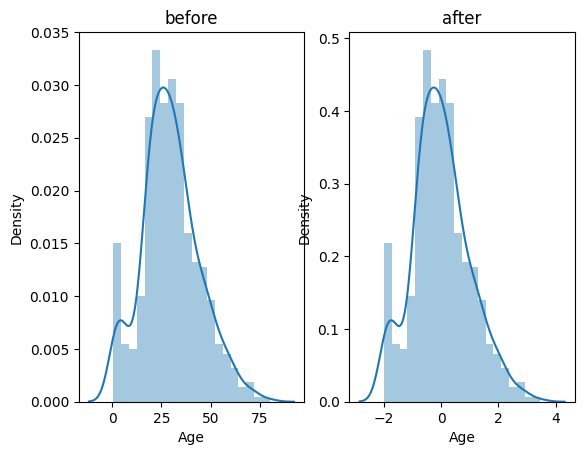

In [115]:
plt.subplot(121)
sns.distplot(x_train.Age)
plt.title("before")
plt.subplot(122)
sns.distplot(x_trained.Age)
plt.title("after")

Text(0.5, 1.0, 'after')

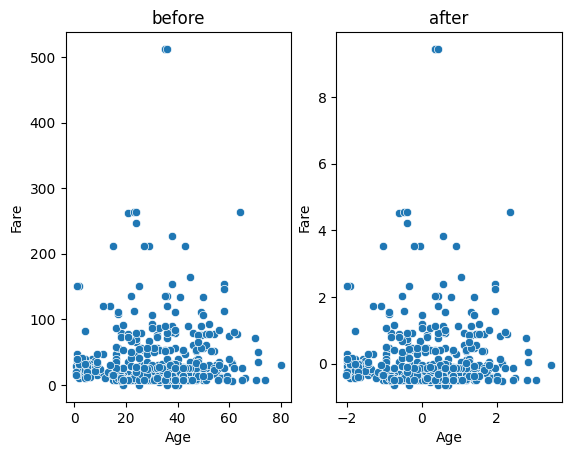

In [122]:
plt.subplot(121)
sns.scatterplot(x=x_train.Age,y=x_train.Fare)
plt.title("before")
plt.subplot(122)
sns.scatterplot(x=x_trained.Age,y=x_trained.Fare)
plt.title("after")
